In [8]:
import os
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter("ignore", category=FutureWarning)

In [9]:

def load_files():
    file_tree = list(os.walk('/kaggle/input'))
    i = 0
    while i < len(file_tree):
        current_root, _, file_list = file_tree[i]
        j = 0
        while j < len(file_list):
            print(os.path.join(current_root, file_list[j]))
            j += 1
        i += 1
    sample_submission = pd.read_csv('/kaggle/input/store-sales-time-series-forecasting/sample_submission.csv')
    print("Sample Submission:")
    print(sample_submission.head())
    test_dataframe = pd.read_csv('/kaggle/input/store-sales-time-series-forecasting/test.csv')
    print("Test Data:")
    print(test_dataframe.head())
    _ = test_dataframe.count()
    train_dataframe = pd.read_csv('/kaggle/input/store-sales-time-series-forecasting/train.csv')
    print("Train Data:")
    print(train_dataframe.head())
    return sample_submission, test_dataframe, train_dataframe


In [10]:
def prepare_series(data, store=1, category='PRODUCE'):
    subset = data[(data['store_nbr'] == store) & (data['family'] == category)][['date', 'sales']].copy()
    subset['date'] = pd.to_datetime(subset['date'])
    subset.set_index('date', inplace=True)
    subset = subset.asfreq('D')
    subset = subset.fillna(method='ffill')
    return subset


In [11]:
def run_forecast(series, order=(5, 1, 0), steps=90):
    arima_model = ARIMA(series, order=order)
    model_result = arima_model.fit()
    predictions = model_result.forecast(steps=steps)
    return predictions, model_result

def build_forecast_frame(predictions, last_date):
    date_range = pd.date_range(start=last_date, periods=len(predictions) + 1, freq='D')[1:]
    return pd.DataFrame({'date': date_range, 'forecast_sales': predictions.values})


In [12]:
def plot_forecast(actual, forecast):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x=actual.index, y=actual['sales'], label='Actual Sales', color='blue')
    sns.lineplot(x=forecast['date'], y=forecast['forecast_sales'], label='Forecast Sales', color='red')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.title('Sales Forecast')
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

def additional_visualizations(train_df):
    train_df['date'] = pd.to_datetime(train_df['date'])
    
    daily_sales = train_df.groupby('date')['sales'].sum().reset_index()
    plt.figure(figsize=(14, 7))
    sns.lineplot(data=daily_sales, x='date', y='sales')
    plt.title('Overall Daily Sales')
    plt.xlabel('Date')
    plt.ylabel('Sales')
    plt.xticks(rotation=45)
    plt.show()
    
    plt.figure(figsize=(10, 5))
    sns.histplot(train_df['sales'], bins=50, kde=True)
    plt.title('Sales Distribution')
    plt.xlabel('Sales')
    plt.ylabel('Frequency')
    plt.show()
    
    numeric_data = train_df.select_dtypes(include=np.number)
    corr_matrix = numeric_data.corr()
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlation Heatmap')
    plt.show()
    
    avg_sales = train_df.groupby(['store_nbr', 'family'])['sales'].mean().reset_index()
    plt.figure(figsize=(12, 6))
    sns.barplot(data=avg_sales, x='store_nbr', y='sales', hue='family')
    plt.title('Average Sales by Store and Family')
    plt.xlabel('Store Number')
    plt.ylabel('Average Sales')
    plt.legend(title='Family')
    plt.show()


In [13]:
def create_submission(series, test_set, order=(5, 1, 0), steps=28512):
    arima_model = ARIMA(series, order=order)
    model_result = arima_model.fit()
    predictions = model_result.forecast(steps=steps)
    submission_df = pd.DataFrame({'id': test_set['id'], 'sales': predictions})
    submission_df = submission_df[['id', 'sales']]
    submission_df.to_csv('/kaggle/working/submission.csv', index=False)
    print("submission.csv has been created successfully!")
    return submission_df


/kaggle/input/store-sales-time-series-forecasting/oil.csv
/kaggle/input/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/store-sales-time-series-forecasting/stores.csv
/kaggle/input/store-sales-time-series-forecasting/train.csv
/kaggle/input/store-sales-time-series-forecasting/test.csv
/kaggle/input/store-sales-time-series-forecasting/transactions.csv
Sample Submission:
        id  sales
0  3000888    0.0
1  3000889    0.0
2  3000890    0.0
3  3000891    0.0
4  3000892    0.0
Test Data:
        id        date  store_nbr      family  onpromotion
0  3000888  2017-08-16          1  AUTOMOTIVE            0
1  3000889  2017-08-16          1   BABY CARE            0
2  3000890  2017-08-16          1      BEAUTY            2
3  3000891  2017-08-16          1   BEVERAGES           20
4  3000892  2017-08-16          1       BOOKS            0
Train Data:
   id        date  store_nbr      family  sales  

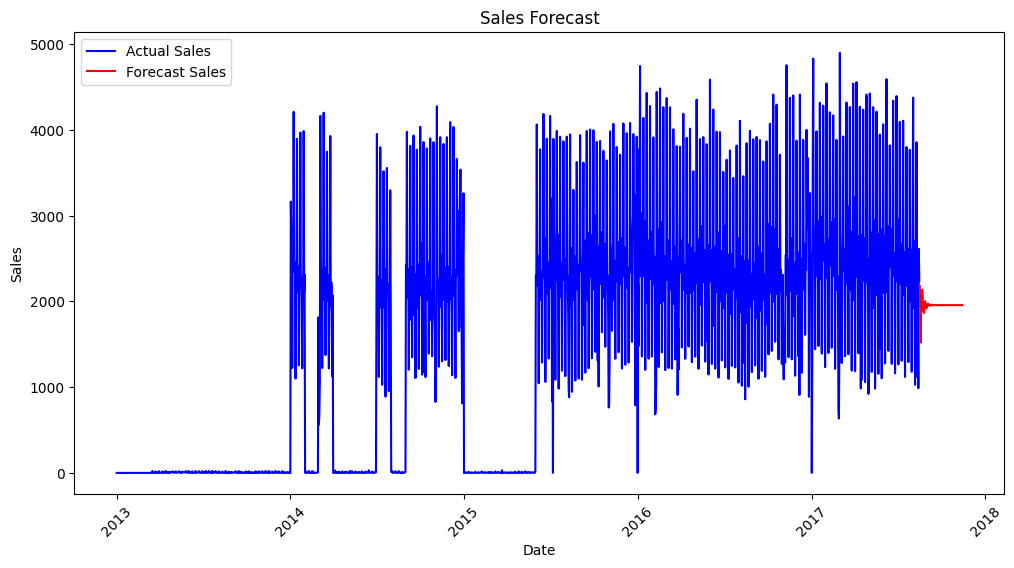

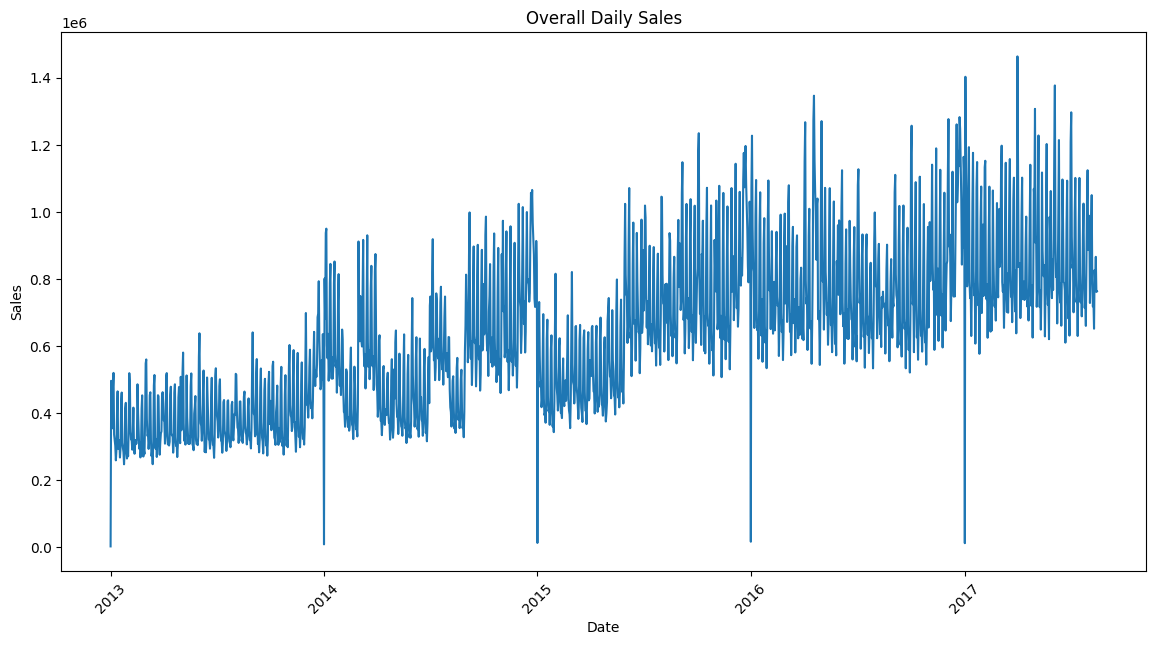

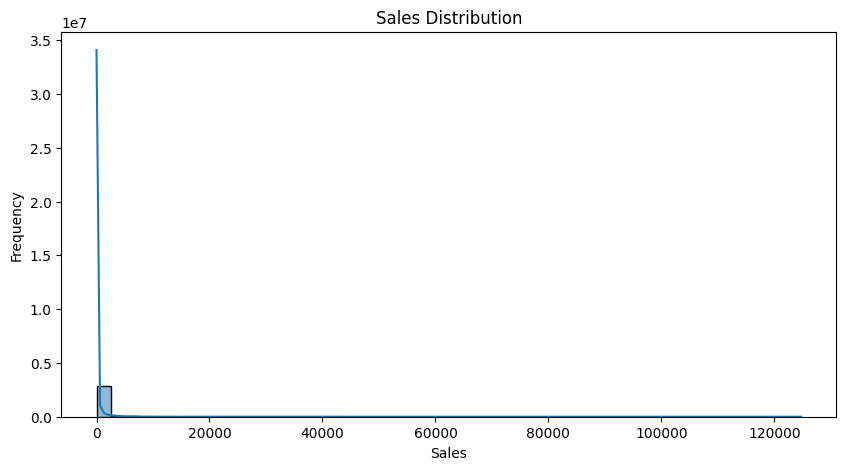

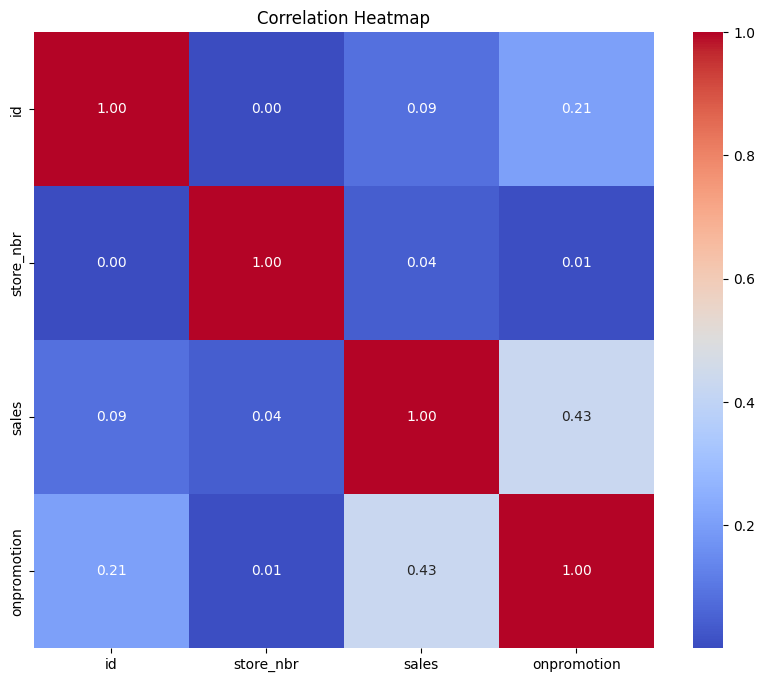

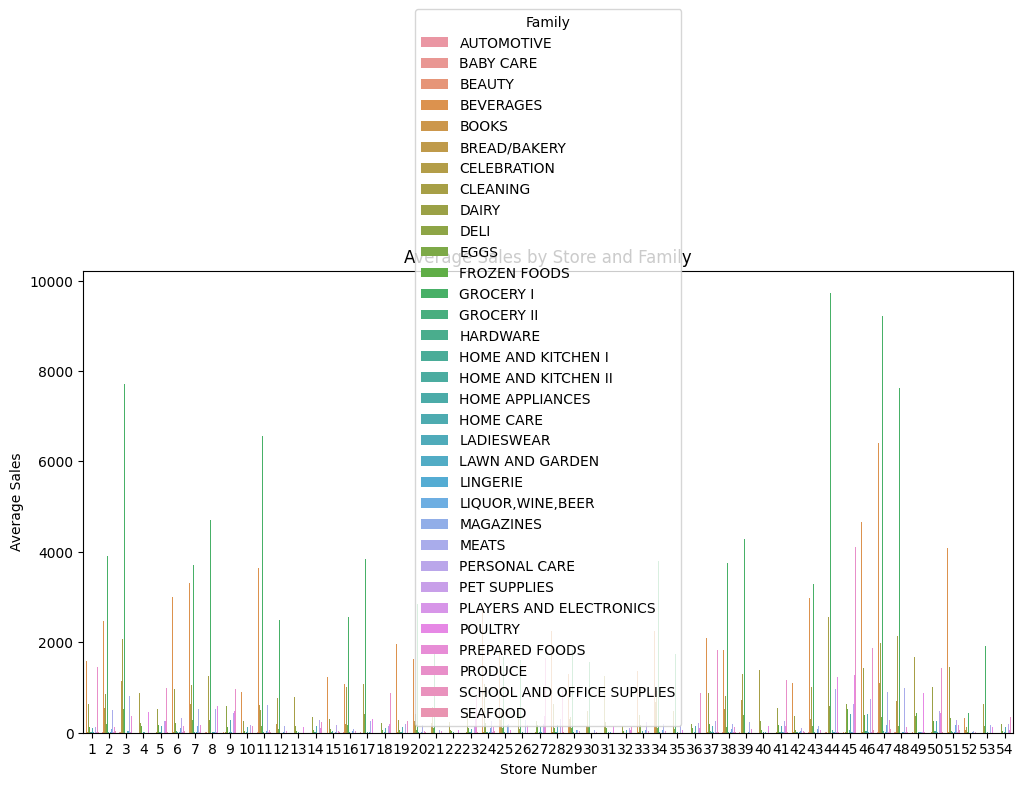

submission.csv has been created successfully!
Columns in time series data: Index(['sales'], dtype='object')
Submission DF row count:
id       28512
sales    28512
dtype: int64


In [14]:

sample_sub, test_data, train_data = load_files()
ts_series = prepare_series(train_data, store=1, category='PRODUCE')


forecast_vals, model_summary = run_forecast(ts_series['sales'], order=(5, 1, 0), steps=90)
print(model_summary.summary())

forecast_frame = build_forecast_frame(forecast_vals, ts_series.index[-1])
print("Forecast DataFrame:")
print(forecast_frame.head())


ts_series.replace([np.inf, -np.inf], np.nan, inplace=True)
forecast_frame.replace([np.inf, -np.inf], np.nan, inplace=True)
ts_series.dropna(inplace=True)
forecast_frame.dropna(inplace=True)


plot_forecast(ts_series, forecast_frame)

additional_visualizations(train_data)
submission_df = create_submission(ts_series['sales'], test_data, order=(5, 1, 0), steps=28512)
print("Columns in time series data:", ts_series.columns)
print("Submission DF row count:")
print(submission_df.count())



